## Image Classification
Image classification using CNN  
Framework: pytorch   
Dataset name: Intel Image Classification  
Number of classes: 6  
Class Names: 'buildings','forest','glacier','mountain','sea','street'

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import os
from PIL import Image
from tqdm import tqdm
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, datasets
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [5]:
class IntelPredictDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        # List all image files in the directory
        self.image_files = [f for f in os.listdir(root_dir) if f.endswith(('.jpg', '.jpeg', '.png'))]

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_name = self.image_files[idx]
        img_path = os.path.join(self.root_dir, img_name)

        # Load image and ensure it's RGB
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        # Returning img_name helps identify which file matches which prediction
        return image, img_name

In [ ]:
# Creating transforms
train_transform = transforms.Compose([
    transforms.Resize(150),                             # Make sure that the image dimension is 150x150
    transforms.RandomCrop(128),                         # Crops the image to a size 128x128 to be easier to downscale
    transforms.RandomHorizontalFlip(),                  # Random Horiztontal Flips
    transforms.ToTensor(),                              # Min Max normaliztion then rearrange of dimensions(Channels, Height, Width)
    transforms.Normalize(mean=[0.485, 0.456, 0.406],    # Normalization over mean and std
                         std=[0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],std=[0.229, 0.224, 0.225])
])

# Importing dataset from my current directory
train_dir = './data/intel_dataset/seg_train/seg_train'
val_dir = './data/intel_dataset/seg_test/seg_test'
test_dir = './data/intel_dataset/seg_pred/seg_pred'

train_ds = datasets.ImageFolder(train_dir,transform=train_transform)
val_ds = datasets.ImageFolder(val_dir,transform=val_test_transform)
test_ds = IntelPredictDataset(test_dir,transform=val_test_transform)

# Dataloader
train_dl = DataLoader(train_ds,batch_size=64,shuffle=True,num_workers=2)
val_dl = DataLoader(val_ds,batch_size=64,shuffle=False,num_workers=2)
test_dl = DataLoader(test_ds,batch_size=64,shuffle=False,num_workers=2)

In [7]:
print(f'Dataset Classes: {train_ds.classes}')
print(f'Dataset Class Indeces: {train_ds.class_to_idx}')
print(f'Number of Training images: {len(train_ds)}')
print(f'Number of Validation images: {len(val_ds)}')
print(f'Number of Testing images: {len(test_ds)}')

Dataset Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Dataset Class Indeces: {'buildings': 0, 'forest': 1, 'glacier': 2, 'mountain': 3, 'sea': 4, 'street': 5}
Number of Training images: 14034
Number of Validation images: 3000
Number of Testing images: 7301


In [8]:
def show(image):
    img = image.numpy()
    img = img.transpose(1,2,0)
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    img = img*std+mean
    img = np.clip(img,0,1)
    return img

images,labels = next(iter(train_dl))
classes = train_ds.classes

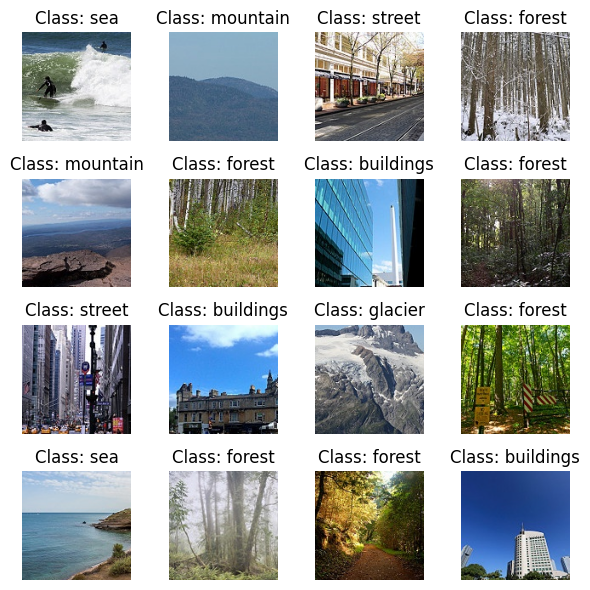

In [9]:
fig = plt.figure(figsize=(6,6))
n=16
for i in range(n):
    ax = fig.add_subplot(4,4,i+1)
    img = show(images[i])
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(f'Class: {classes[labels[i]]}')
fig.tight_layout()

## Model Configuration  
Model Architecture: VGG  
I built the model from scratch  
Input Size: 3 x 128 x 128  
Number of Output Classes: 6  

In [10]:
# Building Model
class Classifier(nn.Module):
    def __init__(self):
        super(Classifier,self).__init__()
        # 128 x 128 -> 64 x 64
        self.block1 = nn.Sequential(
            nn.Conv2d(3,64,kernel_size=3,padding='same',bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64,64,kernel_size=3,padding='same',bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2,stride=2,padding=0)
        )
        # 64 x 64 -> 32 x 32
        self.block2 = nn.Sequential(
            nn.Conv2d(64,128,kernel_size=3,padding='same',bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128,128,kernel_size=3,padding='same',bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2,stride=2,padding=0)
        )
        # 32 x 32 -> 16 x 16
        self.block3 = nn.Sequential(
            nn.Conv2d(128,256,kernel_size=3,padding='same',bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256,256,kernel_size=3,padding='same',bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256,256,kernel_size=3,padding='same',bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2,stride=2,padding=0)
        )
        # 16 x 16 -> 8 x 8
        self.block4 = nn.Sequential(
            nn.Conv2d(256,512,kernel_size=3,padding='same',bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Conv2d(512,512,kernel_size=3,padding='same',bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Conv2d(512,512,kernel_size=3,padding='same',bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2,stride=2,padding=0)
        )
        self.gap = nn.AdaptiveAvgPool2d((1,1))
        self.flatten = nn.Flatten()
        self.classifier = nn.Sequential(
            nn.Linear(512,1000),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.6),
            nn.Linear(1000,1000),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.6),
            nn.Linear(1000,6)
        )

    def forward(self,x):
        x=self.block1(x)
        x=self.block2(x)
        x=self.block3(x)
        x=self.block4(x)
        x=self.gap(x)
        x=self.flatten(x)
        x=self.classifier(x)
        return x

In [11]:
model = Classifier()
model = model.to(device)
print(model)

Classifier(
  (block1): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=same, bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=same, bias=False)
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=same, bias=False)
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=same, bias=False)
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride

In [12]:
# Loss & Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(),lr=0.001,weight_decay=0.001)

In [13]:
# Model Training Functions
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    # Looping over the dataset batches and performing optimizations
    for images,labels in tqdm(loader,desc='Train',leave=False):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()                               # Zeroing the gradient storage
        outputs = model(images)                             # Predicting the labels
        loss = criterion(outputs,labels)                    # Calculating the loss of the batch
        loss.backward()                                     # Back Propagation
        optimizer.step()                                    # Updating the weights

        running_loss += loss.item() * images.size(0)        # Updating the epoch loss with the loss of the current batch (image loss x batch size)
        _,preds = outputs.max(1)                            # Looking for the class index of the highest probability (similar to argmax)
        correct += (preds == labels).sum().item()           # Compares the predictions to the true labels. It counts how many the model got right in this batch and adds it to correct
        total += labels.size(0)                             # Counts how many total images have been processed so far

    epoch_loss = running_loss/total
    epoch_acc = correct/total
    return epoch_loss,epoch_acc

# Model Validation Function
@torch.no_grad()
def validation(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    for images,labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs,labels)

        running_loss += loss.item() * images.size(0)
        _,preds = outputs.max(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss/total
    epoch_acc = correct/total
    return epoch_loss,epoch_acc

In [ ]:
# Model Training
epochs = 60
best_epoch = 0
best_val_acc = 0.0

total_train_loss = [0.0 for _ in range(epochs)]  # List for each training epoch loss
total_train_acc = [0.0 for _ in range(epochs)]   # List for each training epoch accuracy
total_val_loss = [0.0 for _ in range(epochs)]    # List for each validation epoch loss
total_val_acc = [0.0 for _ in range(epochs)]     # List for each validation epoch accuracy

for epoch in range(epochs):
    train_loss, train_acc = train_epoch(model=model,loader=train_dl,optimizer=optimizer,criterion=criterion,device=device)
    total_train_loss[epoch] = train_loss
    total_train_acc[epoch] = train_acc
    val_loss, val_acc = validation(model=model,loader=train_dl,criterion=criterion,device=device)
    total_val_loss[epoch] = val_loss
    total_val_acc[epoch] = val_acc
    print(f'Epoch {epoch+1}/{epochs}: '
          f'- train_loss: {train_loss:.4f}, train_acc: {train_acc:.4f}'
          f' - val_loss: {val_loss:.4f}, val_acc: {val_acc:.4f}')

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch + 1

Epoch 1/60: - train_loss: 1.1812, train_acc: 0.4587 - val_loss: 1.2949, val_acc: 0.4276


Epoch 2/60: - train_loss: 1.0148, train_acc: 0.5259 - val_loss: 1.3876, val_acc: 0.4447


Epoch 3/60: - train_loss: 0.9739, train_acc: 0.5630 - val_loss: 1.0468, val_acc: 0.5658


Epoch 4/60: - train_loss: 0.8985, train_acc: 0.6333 - val_loss: 1.0079, val_acc: 0.5921


Epoch 5/60: - train_loss: 0.7990, train_acc: 0.6964 - val_loss: 0.7945, val_acc: 0.7003


...

Epoch 56/60: - train_loss: 0.3100, train_acc: 0.8927 - val_loss: 0.3017, val_acc: 0.8932


Epoch 57/60: - train_loss: 0.3139, train_acc: 0.8942 - val_loss: 0.2910, val_acc: 0.8977


Epoch 58/60: - train_loss: 0.3112, train_acc: 0.8932 - val_loss: 0.4612, val_acc: 0.8487


Epoch 59/60: - train_loss: 0.3091, train_acc: 0.8934 - val_loss: 0.2710, val_acc: 0.9044


Epoch 60/60: - train_loss: 0.3130, train_acc: 0.8953 - val_loss: 0.3001, val_acc: 0.8943


## Model Evaluation  
* Graphs  
* Accuracy Score
* Classification Report
* Confusion Matrix

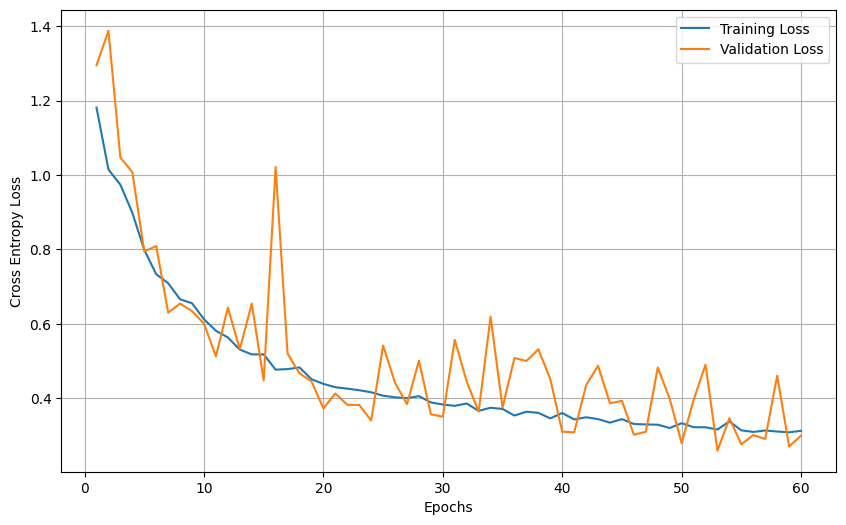

In [15]:
# Training & validation loss vs epochs
e = range(1,epochs+1)
plt.figure(figsize=(10,6))
plt.plot(e,total_train_loss,label="Training Loss")
plt.plot(e,total_val_loss,label="Validation Loss")

plt.xlabel('Epochs')
plt.ylabel('Cross Entropy Loss')

plt.grid(True)
plt.legend()
plt.show()

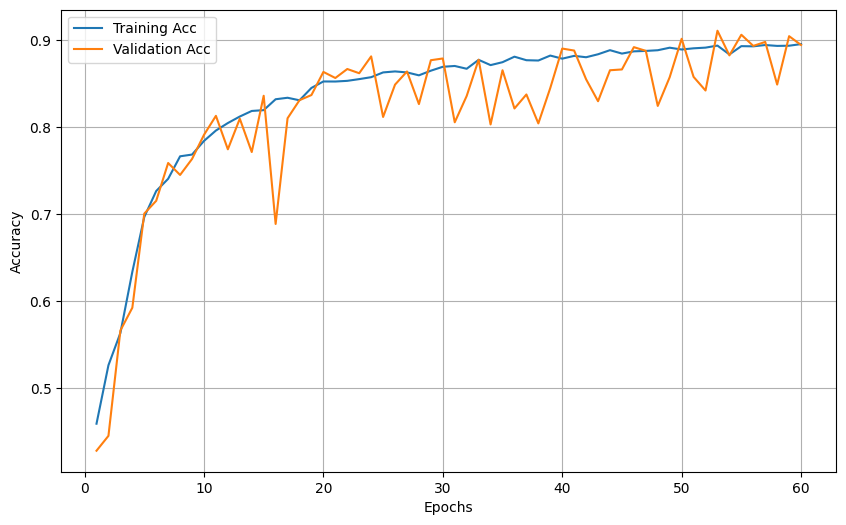

In [16]:
# Training & validation accuracy vs epochs
e = range(1,epochs+1)
plt.figure(figsize=(10,6))
plt.plot(e,total_train_acc,label="Training Acc")
plt.plot(e,total_val_acc,label="Validation Acc")

plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.grid(True)
plt.legend()
plt.show()

In [17]:
# Evaluation Function
@torch.no_grad()
def evaluation_with_examples(model, loader, classes, device, max_examples_per_type=16):
    model.eval()

    all_labels = []
    all_preds = []

    correct_examples = []
    wrong_examples = []

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _,preds = outputs.max(1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

        for i in range(len(images)):
            img_cpu = images[i].cpu()
            true_label = labels[i].cpu().item()
            pred_label = preds[i].cpu().item()

            example = {
                'image': img_cpu,
                'true': true_label,
                'pred': pred_label
            }

            if true_label == pred_label:
                if len(correct_examples) < max_examples_per_type:
                    correct_examples.append(example)
            else:
                if len(wrong_examples) < max_examples_per_type:
                    wrong_examples.append(example)

    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)

    # Overall Accuracy
    accuracy = (all_labels == all_preds).mean()
    print(f'Model Accuracy: {accuracy * 100:.2f}%')

    # Print precision, recall & F1-score
    print(classification_report(all_labels,all_preds,target_names=classes,digits=4))

    # Confusion Matrix
    cm = confusion_matrix(all_labels,all_preds)

    return all_labels, all_preds, wrong_examples, correct_examples, accuracy, cm

In [18]:
# Examples display function
def show_examples(examples,classes,title,cols=4):
    if(len(examples)) == 0:
        print(f'No examples found for: {title}')
        return

    rows = int(np.ceil(len(examples) / cols))
    plt.figure(figsize=(4 * cols, 4 * rows))

    for i, ex in enumerate(examples):
        plt.subplot(rows, cols, i + 1)
        img = show(ex["image"])
        plt.imshow(img)
        plt.title(f"True: {classes[ex['true']]}\nPred: {classes[ex['pred']]}")
        plt.axis("off")

    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

In [19]:
# Evaluate the Model
all_labels, all_preds, wrong_examples, correct_examples, accuracy, cm =evaluation_with_examples(model=model,
                                                                                                loader=val_dl,
                                                                                                classes=classes,
                                                                                                device=device,
                                                                                                )

Model Accuracy: 80.87%
              precision    recall  f1-score   support

   buildings     0.8422    0.9039    0.8720       437
      forest     0.9566    0.9768    0.9666       474
     glacier     0.9448    0.3092    0.4659       553
    mountain     0.6356    0.9238    0.7531       525
         sea     0.7547    0.9471    0.8400       510
      street     0.9266    0.8563    0.8900       501

    accuracy                         0.8087      3000
   macro avg     0.8434    0.8195    0.7979      3000
weighted avg     0.8422    0.8087    0.7889      3000



<Figure size 800x800 with 0 Axes>

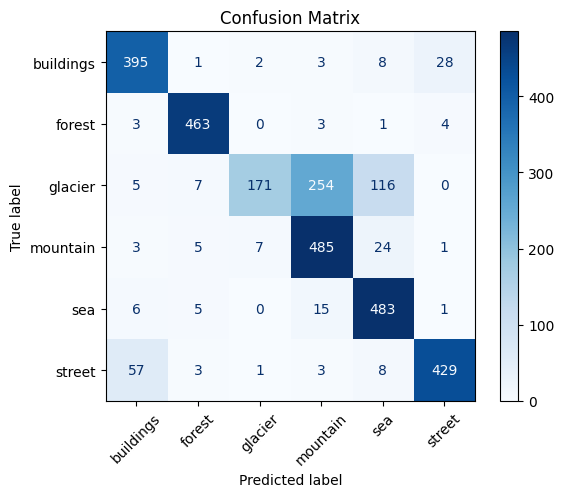

In [20]:
# Display Confusion Matrix
plt.figure(figsize=(8,8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=classes)
disp.plot(cmap='Blues', xticks_rotation=45, values_format='d')
plt.title("Confusion Matrix")
plt.show()

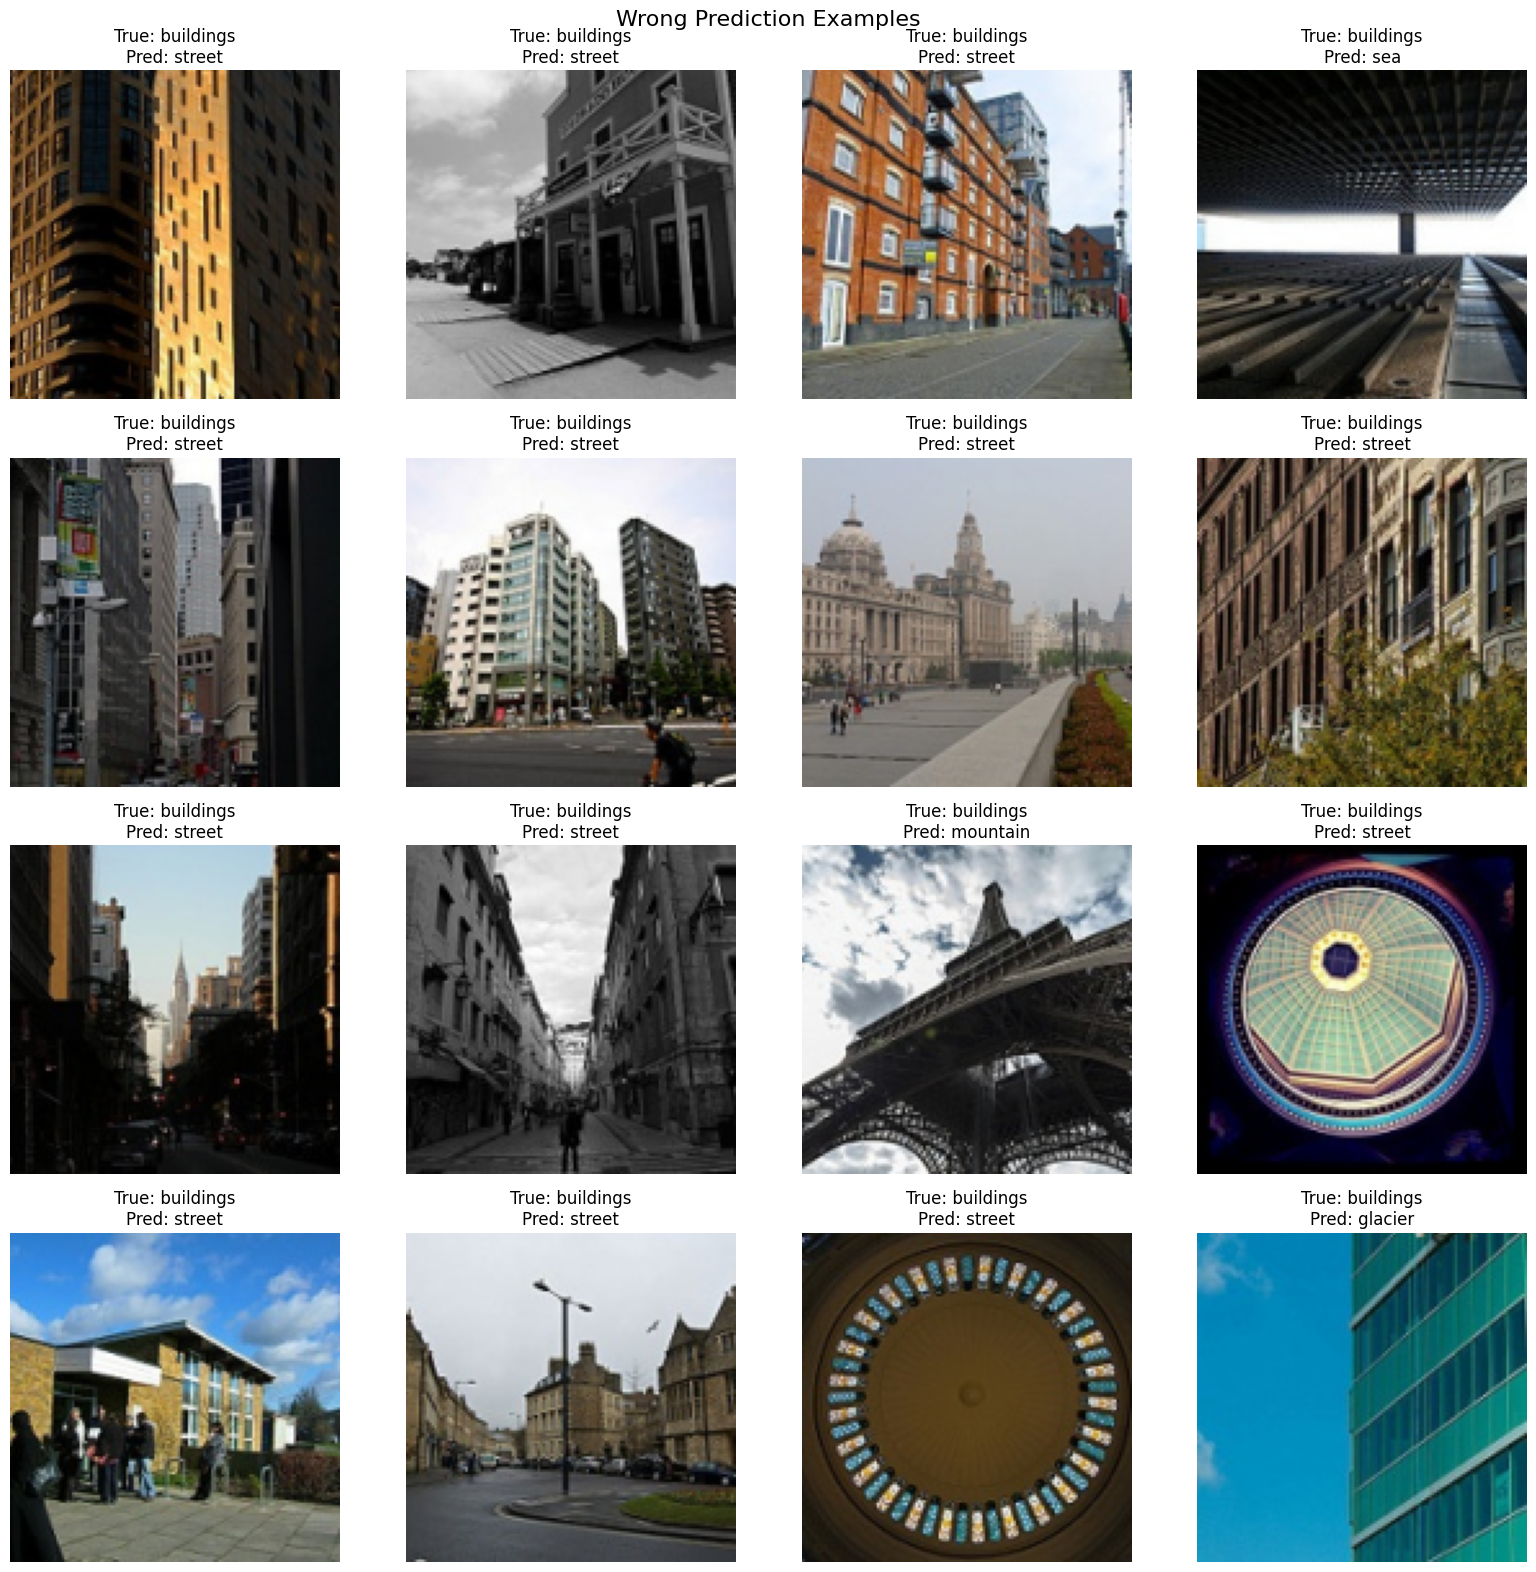

In [21]:
# Display Wrong Examples
show_examples(wrong_examples,classes=classes,title='Wrong Prediction Examples')

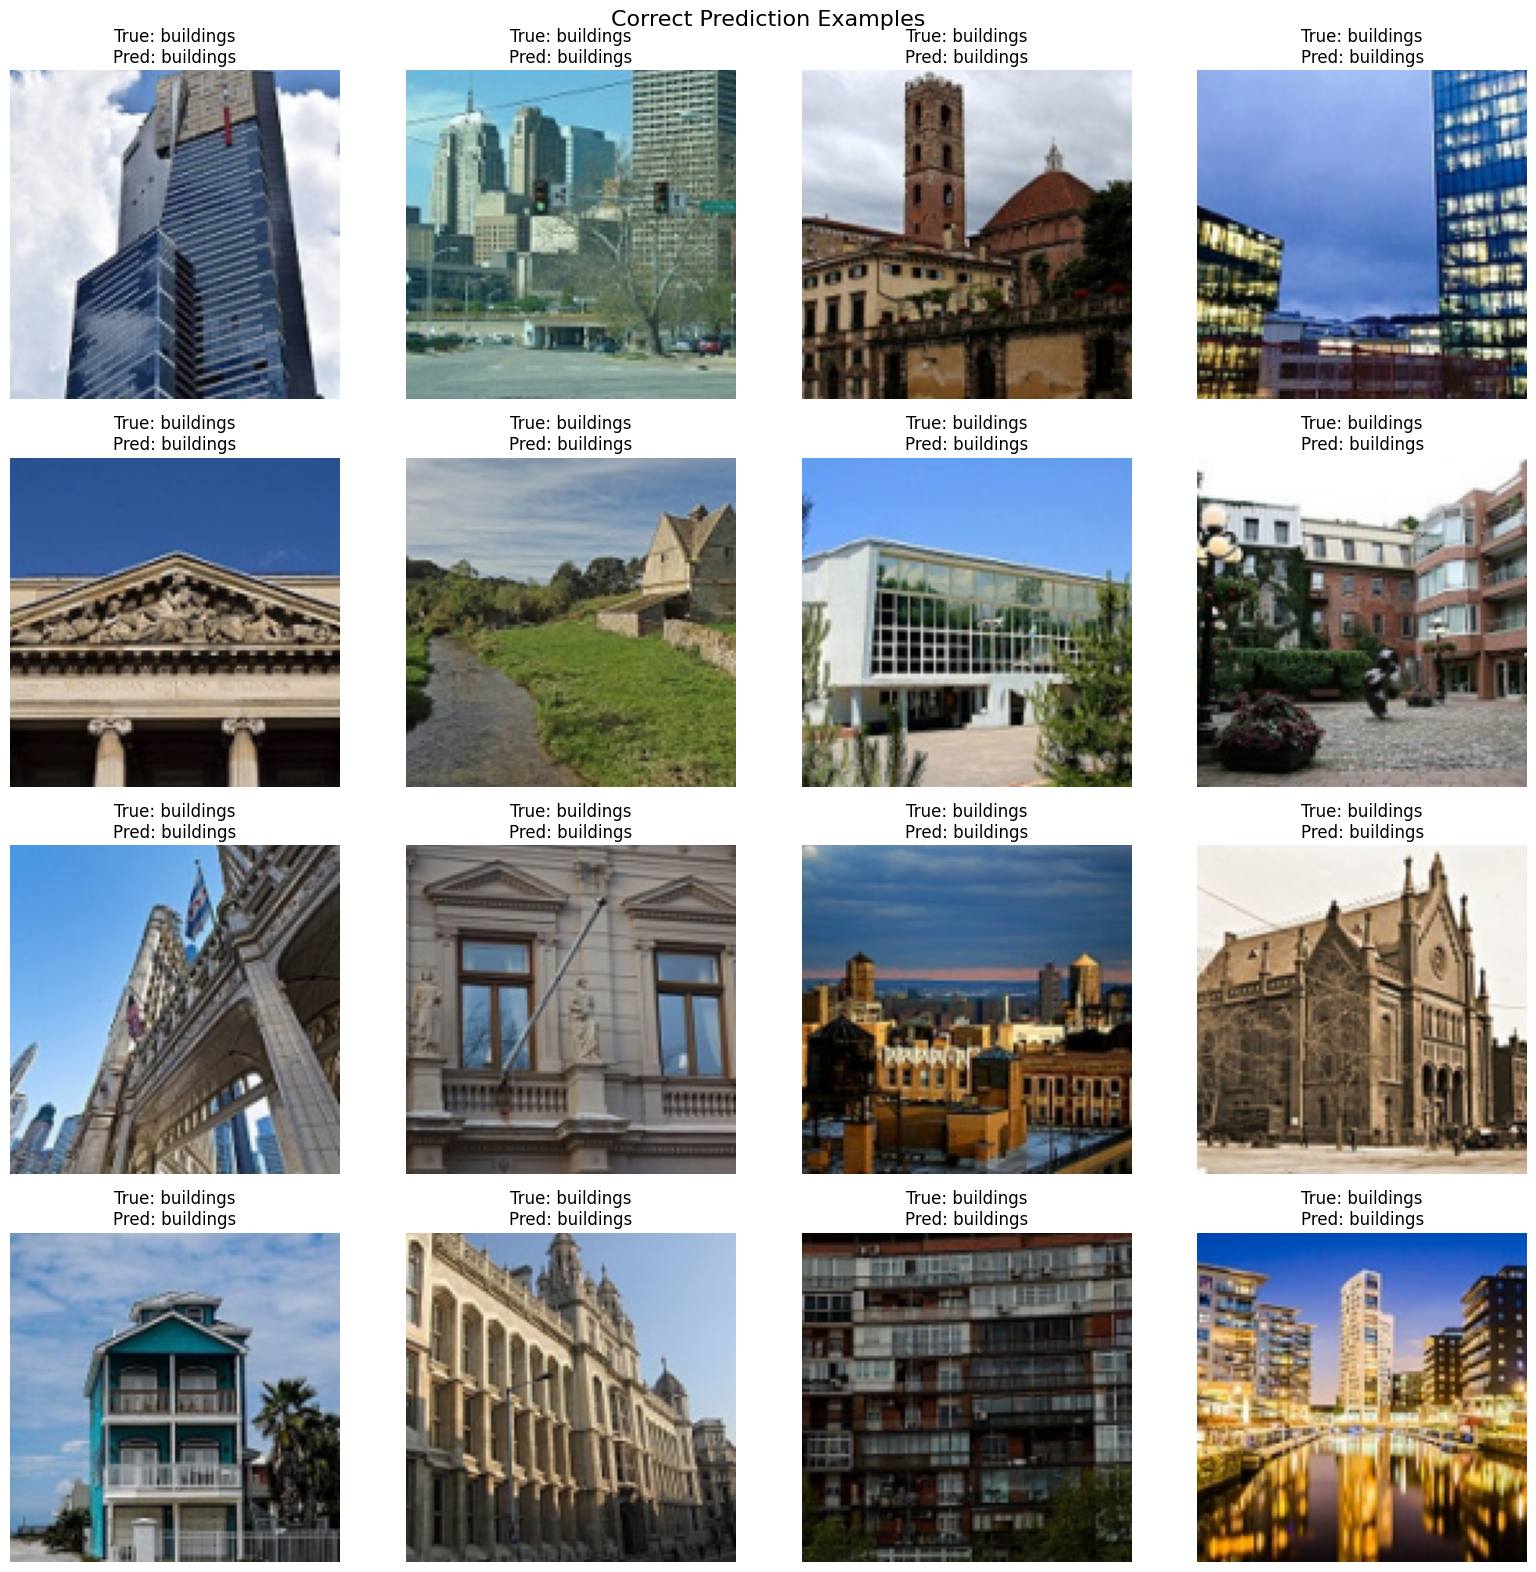

In [22]:
# Display Correct Examples
show_examples(correct_examples,classes=classes,title='Correct Prediction Examples')

## Model Saving & Loading

In [ ]:
# Saving the model
checkpoint = {
        "model_state_dict": model.state_dict(),
        "class_names": classes,
        "class_to_idx": train_ds.class_to_idx,
        "image_size": 128,
        "architecture_name": 'VGG',
        "best_metric": best_val_acc,
        "epoch": best_epoch,
    }
save_path="best_checkpoint_intel.pth"
torch.save(checkpoint, save_path)
print(f"Checkpoint saved to: {save_path}")

Checkpoint saved to: best_checkpoint_intel.pth


In [24]:
# Loading the model
best_model = Classifier().to(device)
checkpoint_path="best_checkpoint_intel.pth"
checkpoint = torch.load(checkpoint_path, map_location=device)

best_model.load_state_dict(checkpoint["model_state_dict"])
best_model.to(device)

print(checkpoint["class_names"])
print(checkpoint["class_to_idx"])
print(checkpoint["image_size"])
print(checkpoint["architecture_name"])
print(checkpoint["best_metric"])
print(checkpoint["epoch"])

['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
{'buildings': 0, 'forest': 1, 'glacier': 2, 'mountain': 3, 'sea': 4, 'street': 5}
128
VGG
0.910645575032065
59


In [ ]:
# Model Prediction Function
@torch.no_grad()
def predict(model, loader, device):
    model.eval()
    img = []

    images,_ = next(iter(loader))
    images = images.to(device)
    outputs = model(images)
    prob = torch.softmax(outputs, dim=1)
    conf,preds = prob.max(1)

    for i in range(len(images)):
        img.append(images[i].cpu())

    return img, preds, conf

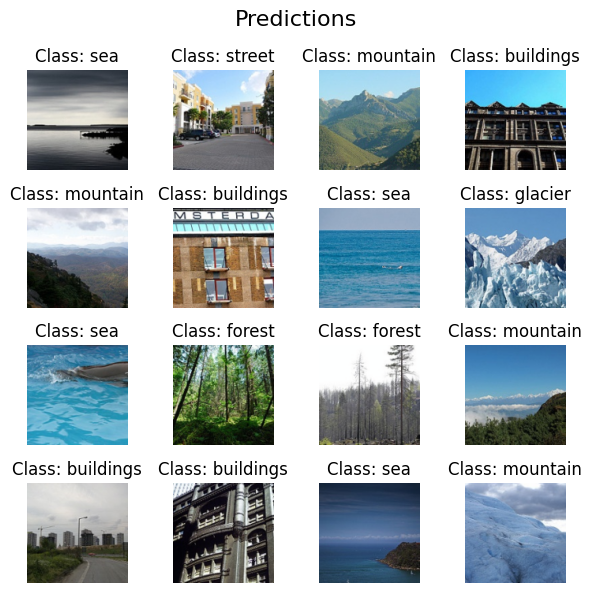

In [ ]:
# Predict & Visualize
pred_images, pred_labels, confidence = predict(best_model,test_dl,device)

fig = plt.figure(figsize=(12,12))
n=16
for i in range(n):
    ax = fig.add_subplot(4,4,i+1)
    img = show(pred_images[i])
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(f'Class: {classes[pred_labels[i]]}\nConfidence: {confidence[i] * 100:.2f}%')
fig.suptitle("Predictions", fontsize = 16)
fig.tight_layout()